# Employee Performance Analysis

#### Code: 10281
### INX Future Inc.

# Result Visualization

## Importing Libraries

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

## Loading Data & Models

In [22]:
# Loading datasets
df = pd.read_excel("C:\\Users\\navee\\Downloads\\INX_Future_Inc_Employee_Performance_CDS_Project\\Data\\Processed\\final_employee_performance_for_model.xlsx")
X_test = pd.read_excel("C:\\Users\\navee\\Downloads\\INX_Future_Inc_Employee_Performance_CDS_Project\\Src\\Models\\X_test.xlsx")
y_test = pd.read_excel("C:\\Users\\navee\\Downloads\\INX_Future_Inc_Employee_Performance_CDS_Project\\Src\\Models\\y_test.xlsx").values.ravel()

# Loading models
lr_model = joblib.load("logistic_model.pkl")
dt_model = joblib.load("decision_tree_model.pkl")
rf_model = joblib.load("random_forest_model.pkl")
gb_model = joblib.load("gradient_boosting_model.pkl")

## Predictions

In [23]:
lr_pred = lr_model.predict(X_test)
dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
gb_pred = gb_model.predict(X_test)

# EXPLORATORY VISUALIZATIONS

## Target Distribution

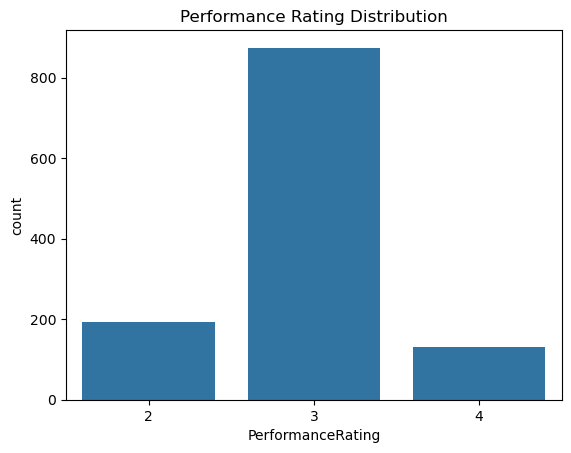

In [24]:
plt.figure()
sns.countplot(x='PerformanceRating', data=df)
plt.title("Performance Rating Distribution")
plt.show()

## Correlation Heatmap

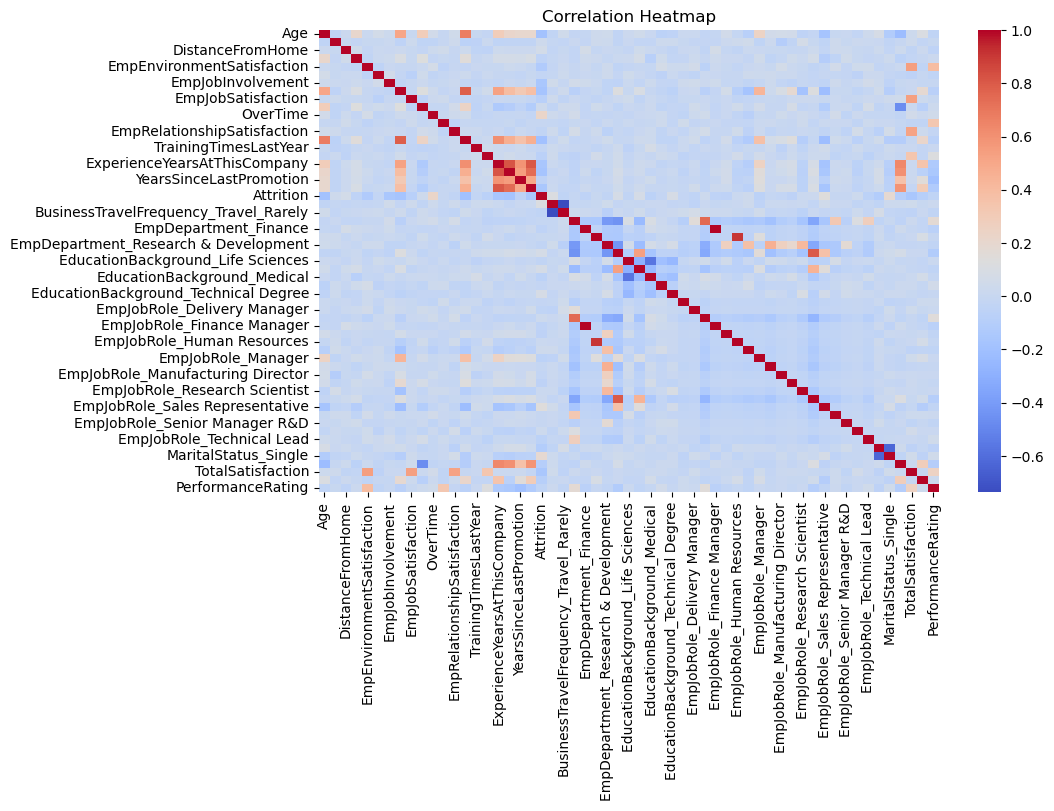

In [25]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include='number').corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Top Features vs Target

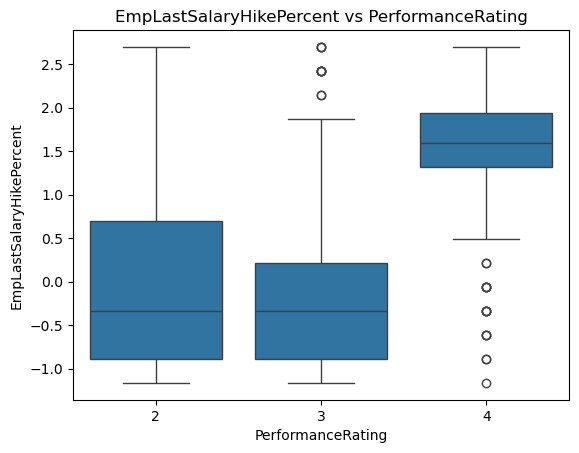

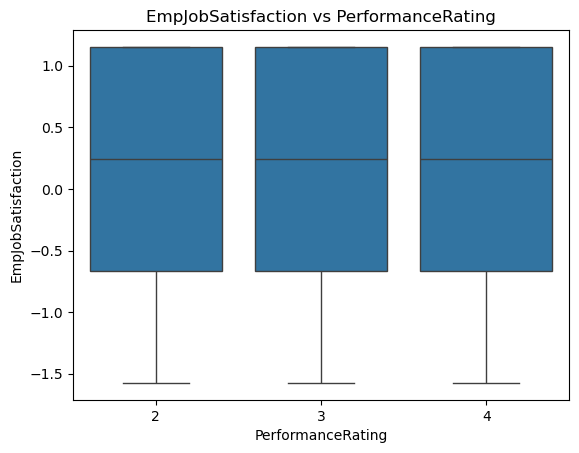

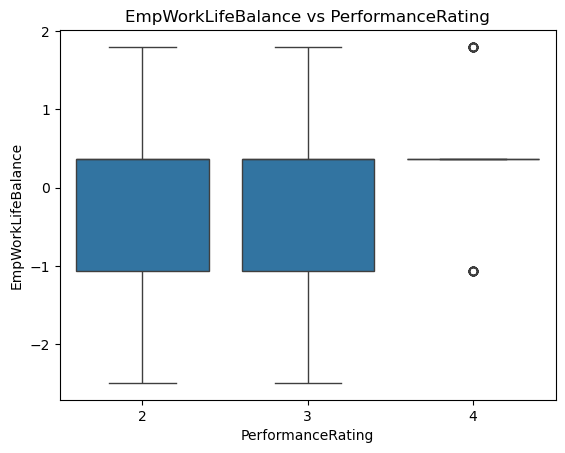

In [26]:
features = ['EmpLastSalaryHikePercent', 'EmpJobSatisfaction', 'EmpWorkLifeBalance']

for col in features:
    plt.figure()
    sns.boxplot(x='PerformanceRating', y=col, data=df)
    plt.title(f"{col} vs PerformanceRating")
    plt.show()

# MODEL PERFORMANCE VISUALS`

## Accuracy Comparison

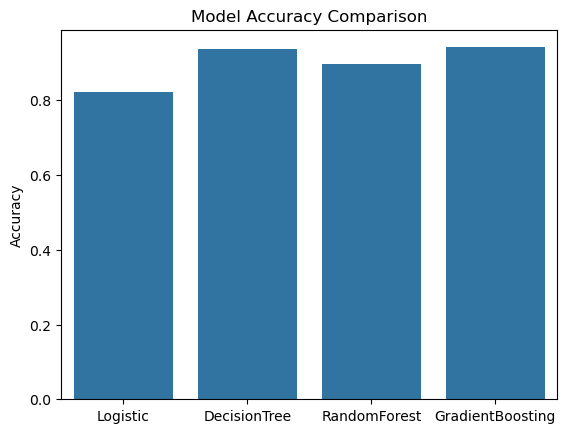

In [27]:
results = {
    'Logistic': accuracy_score(y_test, lr_pred),
    'DecisionTree': accuracy_score(y_test, dt_pred),
    'RandomForest': accuracy_score(y_test, rf_pred),
    'GradientBoosting': accuracy_score(y_test, gb_pred)
}

models = list(results.keys())
scores = list(results.values())

plt.figure()
sns.barplot(x=models, y=scores)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

## Confusion Matrix (Best Model)

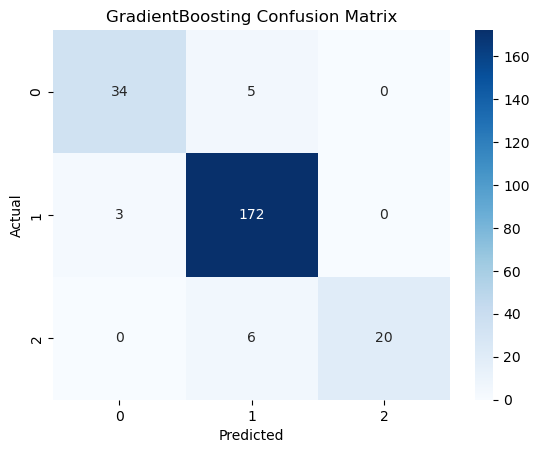

In [28]:
best_model = max(results, key=results.get)

if best_model == 'RandomForest':
    best_pred = rf_pred
elif best_model == 'GradientBoosting':
    best_pred = gb_pred
elif best_model == 'DecisionTree':
    best_pred = dt_pred
else:
    best_pred = lr_pred

cm = confusion_matrix(y_test, best_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"{best_model} Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# FEATURE IMPORTANCE (VERY IMPORTANT)

## Feature Importance (Random Forest)

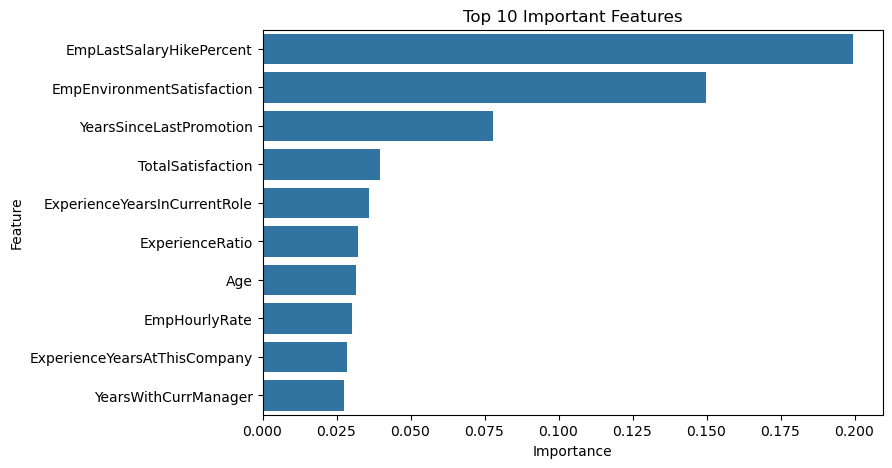

In [29]:
import numpy as np

feature_importance = rf_model.feature_importances_
feature_names = X_test.columns

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title("Top 10 Important Features")
plt.show()

# ACTUAL VS PREDICTED

## Prediction Comparison

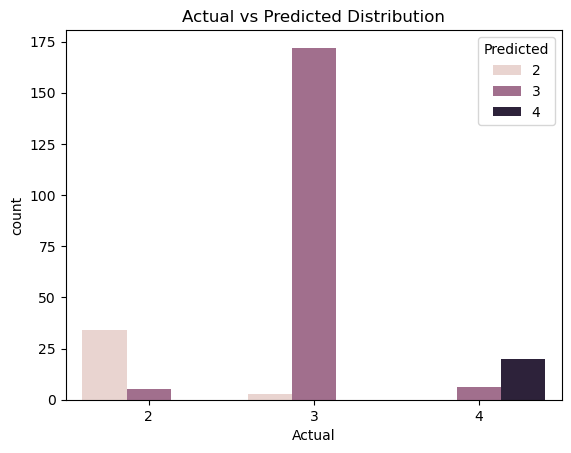

In [30]:
pred_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': best_pred
})

plt.figure()
sns.countplot(x='Actual', hue='Predicted', data=pred_df)
plt.title("Actual vs Predicted Distribution")
plt.show()

Key Observations:
    
Gradient Boosting / Random Forest performs best<br>
Salary hike, satisfaction, and work-life balance are top drivers<br>
Class imbalance handled successfully using SMOTE